# Initialize Model

In [1]:
from Config.config import CONFIG
CONFIG = CONFIG("Generated")


from DyGLib.models.GraphMixer import GraphMixer
from DyGLib.models.TGAT import TGAT
from DyGLib.models.TCL import TCL
from DyGLib.models.CAWN import CAWN
from DyGLib.models.DyGFormer import DyGFormer
from DyGLib.models.MemoryModel import MemoryModel, compute_src_dst_node_time_shifts

from DyGLib.models.modules import TGNN, NeuralNetworkSrcDst, BatchSubgraphs
from DyGLib.utils.DataLoader import get_link_prediction_data
from DyGLib.utils.utils import get_neighbor_sampler, NegativeEdgeSampler

import torch
import numpy as np
import pandas as pd
import seaborn as sns

import random

from IPython.display import SVG
import time

# # Initialization
trained_model_path = CONFIG.model.trained_model_path
edge_feat_path = CONFIG.data.folder + CONFIG.data.edge_feat_file
node_feat_path = CONFIG.data.folder + CONFIG.data.node_feat_file
index_path = CONFIG.data.folder + CONFIG.data.index_file
feature_names_path = CONFIG.data.folder + CONFIG.data.feature_names_file

# get data for training, validation and testing
node_raw_features, edge_raw_features, full_data, train_data, val_data, test_data = \
    get_link_prediction_data(val_ratio=0.1, test_ratio=0.1, node_dim=CONFIG.model.node_dim)

# initialize validation and test neighbor sampler to retrieve temporal graph
full_neighbor_sampler = get_neighbor_sampler(data=full_data, edge_features=edge_raw_features, sample_neighbor_strategy=CONFIG.model.sample_neighbor_strategy,
                                                time_scaling_factor=CONFIG.model.time_scaling_factor, seed=1)
train_neighbor_sampler = get_neighbor_sampler(data=train_data, edge_features=edge_raw_features, sample_neighbor_strategy=CONFIG.model.sample_neighbor_strategy,
                                                time_scaling_factor=CONFIG.model.time_scaling_factor, seed=1)

# create model
if CONFIG.model.model_name == 'TGAT':
    dynamic_backbone = TGAT(num_nodes=node_raw_features.shape[0], node_dim=node_raw_features.shape[1], edge_dim=edge_raw_features.shape[1],
                            time_feat_dim=CONFIG.model.time_feat_dim, num_layers=CONFIG.model.num_layers, num_heads=CONFIG.model.num_heads, dropout=CONFIG.model.dropout, device=CONFIG.model.device)
elif CONFIG.model.model_name in ['JODIE', 'DyRep', 'TGN']:
    # four floats that represent the mean and standard deviation of source and destination node time shifts in the training data, which is used for JODIE
    src_node_mean_time_shift, src_node_std_time_shift, dst_node_mean_time_shift_dst, dst_node_std_time_shift = \
        compute_src_dst_node_time_shifts(train_data.src_node_ids, train_data.dst_node_ids, train_data.node_interact_times)
    dynamic_backbone = MemoryModel(num_nodes=node_raw_features.shape[0], node_dim=node_raw_features.shape[1], edge_dim=edge_raw_features.shape[1],
                                    time_feat_dim=CONFIG.model.time_feat_dim, model_name=CONFIG.model.model_name, num_layers=CONFIG.model.num_layers, num_heads=CONFIG.model.num_heads,
                                    dropout=CONFIG.model.dropout, src_node_mean_time_shift=src_node_mean_time_shift, src_node_std_time_shift=src_node_std_time_shift,
                                    dst_node_mean_time_shift_dst=dst_node_mean_time_shift_dst, dst_node_std_time_shift=dst_node_std_time_shift, device=CONFIG.model.device)
elif CONFIG.model.model_name == 'CAWN':
    dynamic_backbone = CAWN(num_nodes=node_raw_features.shape[0], node_dim=node_raw_features.shape[1], edge_dim=edge_raw_features.shape[1],
                            time_feat_dim=CONFIG.model.time_feat_dim, position_feat_dim=CONFIG.model.position_feat_dim, walk_length=CONFIG.model.walk_length,
                            num_walk_heads=CONFIG.model.num_walk_heads, dropout=CONFIG.model.dropout, device=CONFIG.model.device)
elif CONFIG.model.model_name == 'TCL':
    dynamic_backbone = TCL(num_nodes=node_raw_features.shape[0], node_dim=node_raw_features.shape[1], edge_dim=edge_raw_features.shape[1],
                            time_feat_dim=CONFIG.model.time_feat_dim, num_layers=CONFIG.model.num_layers, num_heads=CONFIG.model.num_heads,
                            num_depths=CONFIG.model.num_neighbors + 1, dropout=CONFIG.model.dropout, device=CONFIG.model.device)
elif CONFIG.model.model_name == 'GraphMixer':
    dynamic_backbone = GraphMixer(num_nodes=node_raw_features.shape[0], node_dim=node_raw_features.shape[1], edge_dim=edge_raw_features.shape[1],
                            time_feat_dim=CONFIG.model.time_feat_dim, num_tokens=CONFIG.model.num_neighbors, num_layers=CONFIG.model.num_layers, dropout=CONFIG.model.dropout, device=CONFIG.model.device)
elif CONFIG.model.model_name == 'DyGFormer':
    dynamic_backbone = DyGFormer(num_nodes=node_raw_features.shape[0], node_dim=node_raw_features.shape[1], edge_dim=edge_raw_features.shape[1],
                                    time_feat_dim=CONFIG.model.time_feat_dim, channel_embedding_dim=CONFIG.model.channel_embedding_dim, patch_size=CONFIG.model.patch_size,
                                    num_layers=CONFIG.model.num_layers, num_heads=CONFIG.model.num_heads, dropout=CONFIG.model.dropout,
                                    max_input_sequence_length=CONFIG.model.max_input_sequence_length, device=CONFIG.model.device)
else:
    raise ValueError(f"Wrong value for model_name {CONFIG.model.model_name}!")

regressor = NeuralNetworkSrcDst(input_dim=node_raw_features.shape[1], num_layers=CONFIG.model.num_reg_layers, hidden_dim=CONFIG.model.hidden_reg_layers_dim)
model = TGNN(dynamic_backbone, regressor)

model.load_state_dict(torch.load(trained_model_path, weights_only=True))
model.to(CONFIG.model.device)
model.eval()

/Users/lms/Documents/Forschung/Shapley4TGNN/.tgnnshap_venv/lib/python3.11/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: dlopen(/Users/lms/Documents/Forschung/Shapley4TGNN/.tgnnshap_venv/lib/python3.11/site-packages/libpyg.so, 0x0006): Library not loaded: /Library/Frameworks/Python.framework/Versions/3.11/Python
  Referenced from: <CA14ED34-FA3D-31FE-B4AD-2B2A8446B324> /Users/lms/Documents/Forschung/Shapley4TGNN/.tgnnshap_venv/lib/python3.11/site-packages/libpyg.so
  Reason: tried: '/Library/Frameworks/Python.framework/Versions/3.11/Python' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/Python.framework/Versions/3.11/Python' (no such file), '/Library/Frameworks/Python.framework/Versions/3.11/Python' (no such file)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/Users/lms/Documents/Forschung/Shapley4TGNN/.tgnnshap_venv/lib/python3.11/site-packages/torch_geo

The dataset has 1260 interactions, involving 1350 different nodes
The training dataset has 987 interactions, involving 1094 different nodes
The validation dataset has 140 interactions, involving 210 different nodes
The test dataset has 70 interactions, involving 90 different nodes
The new node validation dataset has 138 interactions, involving 206 different nodes
The new node test dataset has 70 interactions, involving 90 different nodes
135 nodes were used for the inductive testing, i.e. are never seen during training


TGNN(
  (backbone): TGAT(
    (time_encoder): TimeEncoder(
      (w): Linear(in_features=1, out_features=10, bias=True)
    )
    (temporal_conv_layers): ModuleList(
      (0-1): 2 x MultiHeadAttention(
        (query_projection): Linear(in_features=20, out_features=20, bias=False)
        (key_projection): Linear(in_features=21, out_features=20, bias=False)
        (value_projection): Linear(in_features=21, out_features=20, bias=False)
        (layer_norm): LayerNorm((20,), eps=1e-05, elementwise_affine=True)
        (residual_fc): Linear(in_features=20, out_features=20, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
    )
    (projectors): ModuleList(
      (0-1): 2 x Linear(in_features=30, out_features=10, bias=True)
    )
  )
  (model): NeuralNetworkSrcDst(
    (model): Sequential(
      (0): Linear(in_features=20, out_features=1, bias=True)
    )
  )
)

# Feature Explainer

In [ ]:
from Explainers.Shapley4TGNN.Explainer import ShapleyExplainerFeatures, ShapleyExplainerEvents
from scipy.stats import ks_2samp, ttest_1samp
from tqdm import tqdm
import os

n = 50
top_k = 3
explanations_path = "./explanations.csv"
# Create file
with open(explanations_path, "w") as f:
    f.write("e_id,src,dst,label,timestamp,feature_name,feature_value,shapley_value,explained_e_id,mode\n")

np.random.seed(42)
events_to_explain = np.where(~np.isnan(full_data.labels))[0]
events_to_explain = np.random.choice(events_to_explain, size=n, replace=False)

true_owen_values = []
approx_owen_values = []

explanations = []

exact_explainer = ShapleyExplainerFeatures(model, full_neighbor_sampler, full_data, edge_raw_features, top_k=top_k, feature_names=True, shapley_alg="Exact")
exact_explainer.initialize()

approx_explainer = ShapleyExplainerFeatures(model, full_neighbor_sampler, full_data, edge_raw_features, top_k=top_k, feature_names=True, shapley_alg="MonteCarlo")
approx_explainer.initialize()

for e_id in tqdm(events_to_explain):
    src = int(full_data.src_node_ids[e_id])
    dst = int(full_data.dst_node_ids[e_id])
    timestamp = int(full_data.node_interact_times[e_id])
    
    with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
    # True Owen values
        exact_explanation = exact_explainer.explain_instance(src, dst, timestamp, silent=True)[0]
        # Sort by id then by features
        exact_explanation = np.array(sorted(exact_explanation, key=lambda x: (x[0], x[5])))
        true_owen_values.append(exact_explanation[:,-1].astype(np.float32))
        exact_explanation = pd.DataFrame(exact_explanation, columns=["e_id","src", "dst", "label", "timestamp", "feature_name", "feature_value", "shapley_value"])
        exact_explanation["explained_e_id"] = e_id
        exact_explanation["mode"] = "exact"
        explanations.append(exact_explanation)
        exact_explanation.to_csv(explanations_path, mode='a', header=False)

        # Approximate Owen values
        approx_explanation = approx_explainer.explain_instance(src, dst, timestamp, silent=True)[0]
        approx_explanation = np.array(sorted(approx_explanation, key=lambda x: (x[0], x[5])))
        approx_owen_values.append(approx_explanation[:,-1].astype(np.float32))
        approx_explanation = pd.DataFrame(approx_explanation, columns=["e_id","src", "dst", "label", "timestamp", "feature_name", "feature_value", "shapley_value"])
        approx_explanation["explained_e_id"] = e_id
        approx_explanation["mode"] = "monte_carlo"
        explanations.append(approx_explanation)
        approx_explanation.to_csv(explanations_path, mode='a', header=False)

result = ks_2samp(np.reshape(true_owen_values, -1), np.reshape(approx_owen_values, -1))

print("KS statistic:", result.statistic)
print("p-value:", result.pvalue)

deviations = np.array(true_owen_values) - np.array(approx_owen_values)

result = ttest_1samp(np.abs(np.reshape(deviations, -1)), 0.025, alternative="less")

print("t-statistic:", result.statistic)
print("p-value:", result.pvalue)

print("Mean absolute deviation:", np.mean(np.abs(np.reshape(deviations, -1))))
print("Std. absolute deviation:", np.std(np.abs(np.reshape(deviations, -1))))
print("Max. absolute deviation:", np.max(np.abs(np.reshape(deviations, -1))))


/Users/lms/Documents/Forschung/Shapley4TGNN/.tgnnshap_venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 50/50 [01:02<00:00,  1.25s/it]

KS statistic: 0.06444444444444444
p-value: 0.3077124975241367
t-statistic: -7.867598413722498
p-value: 1.3621008444055991e-14


# Runtime vs. approximation quality 

In [21]:
from Explainers.Shapley4TGNN.Explainer import ShapleyExplainerFeatures, ShapleyExplainerEvents
from scipy.stats import ks_2samp, ttest_1samp
from tqdm import tqdm
import os

n = 5
top_k = 3
num_samples = np.linspace(1, 8, 5).astype(int)

np.random.seed(42)
events_to_explain = np.where(~np.isnan(full_data.labels))[0]
events_to_explain = np.random.choice(events_to_explain, size=n, replace=False)

true_owen_values = []
approx_owen_values = []

explanations = []

results = []

exact_explainer = ShapleyExplainerFeatures(model, full_neighbor_sampler, full_data, edge_raw_features, top_k=top_k, feature_names=True, shapley_alg="Exact")
exact_explainer.initialize()

approx_explainer = ShapleyExplainerFeatures(model, full_neighbor_sampler, full_data, edge_raw_features, top_k=top_k, feature_names=True, shapley_alg="MonteCarlo")
approx_explainer.initialize()

for e_id in tqdm(events_to_explain, desc="Explaining events"):
    src = int(full_data.src_node_ids[e_id])
    dst = int(full_data.dst_node_ids[e_id])
    timestamp = int(full_data.node_interact_times[e_id])
    with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
        # True Owen values
        start_time = time.time()
        exact_explanation = exact_explainer.explain_instance(src, dst, timestamp, silent=True)[0]
        end_time = time.time()
        exact_explanation = np.array(sorted(exact_explanation, key=lambda x: (x[0], x[5])))
        true_owen_values.append(exact_explanation[:,-1].astype(np.float32))
        exact_explanation = pd.DataFrame(exact_explanation, columns=["e_id","src", "dst", "label", "timestamp", "feature_name", "feature_value", "shapley_value"])
        exact_explanation["explained_e_id"] = e_id
        exact_explanation["mode"] = "exact"
        explanations.append(exact_explanation)
        exact_explanation.to_csv(explanations_path, mode='a', header=False)
        results.append({"e_id": e_id, 
                        "time_taken": end_time - start_time,
                        "model": "exact",
                        "num_samples": None,
                        "mean_abs_deviation": None,})
    for s in tqdm(num_samples, desc="Samples for event {}".format(e_id)):
        with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
            # Approximate Owen values
            start_time = time.time()
            approx_explanation = approx_explainer.explain_instance(src, dst, timestamp, silent=True, max_num_samples=s)[0]
            end_time = time.time()
            approx_explanation = np.array(sorted(approx_explanation, key=lambda x: (x[0], x[5])))
            approx_owen_values.append(approx_explanation[:,-1].astype(np.float32))
            approx_explanation = pd.DataFrame(approx_explanation, columns=["e_id","src", "dst", "label", "timestamp", "feature_name", "feature_value", "shapley_value"])
            approx_explanation["explained_e_id"] = e_id
            approx_explanation["mode"] = "monte_carlo"
            explanations.append(approx_explanation)
            approx_explanation.to_csv(explanations_path, mode='a', header=False)
            deviations = np.array(true_owen_values[-1]) - np.array(approx_owen_values[-1])
            mean_abs_deviation = np.mean(np.abs(np.reshape(deviations, -1)))
            results.append({"e_id": e_id, 
                            "time_taken": end_time - start_time,
                            "model": "monte_carlo",
                            "num_samples": s,
                            "mean_abs_deviation": mean_abs_deviation})

results_df = pd.DataFrame(results)
results_df

Explaining events: 100%|██████████| 5/5 [00:16<00:00,  3.26s/it]


,e_id,time_taken,model,num_samples,mean_abs_deviation
0,862,0.753429,exact,NaN,NaN
1,862,0.548435,monte_carlo,1.0,0.138519
2,862,0.538589,monte_carlo,2.0,0.087472
3,862,0.574945,monte_carlo,4.0,0.102466
4,862,0.547778,monte_carlo,6.0,0.025208
5,862,0.545916,monte_carlo,8.0,0.012762
6,610,0.612411,exact,NaN,NaN
7,610,0.391787,monte_carlo,1.0,0.101995
8,610,0.466958,monte_carlo,2.0,0.126298
9,610,0.559748,monte_carlo,4.0,0.098314


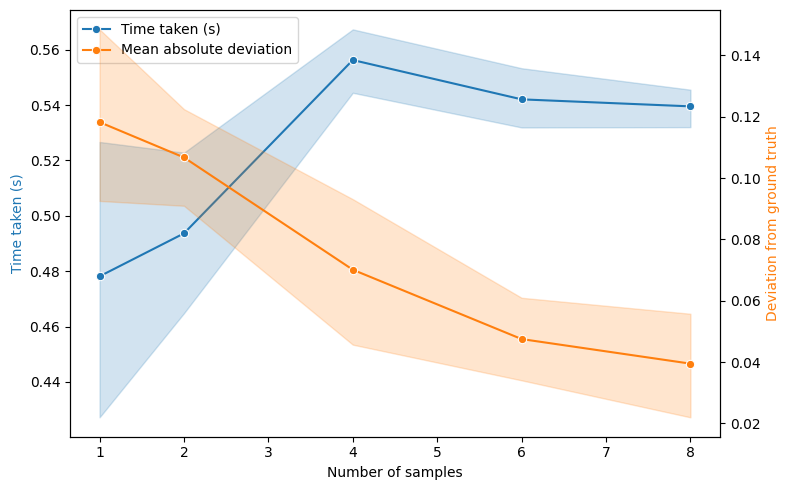

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

df = results_df[results_df["model"] == "monte_carlo"].copy()

time_color = "tab:blue"
deviation_color = "tab:orange"

fig, ax1 = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=df,
    x="num_samples",
    y="time_taken",
    marker="o",
    ax=ax1,
    color=time_color,
    label="Time taken (s)"
)

ax1.set_xlabel("Number of samples")
ax1.set_ylabel("Time taken (s)", color=time_color)
ax1.tick_params(axis="y")

ax2 = ax1.twinx()

sns.lineplot(
    data=df,
    x="num_samples",
    y="mean_abs_deviation",
    marker="o",
    ax=ax2,
    color=deviation_color,
    label="Mean absolute deviation"
)

ax2.set_ylabel("Deviation from ground truth", color=deviation_color)
ax2.tick_params(axis="y")

ax1.get_legend().remove()
ax2.get_legend().remove()

# Combined legend
lines = ax1.get_lines() + ax2.get_lines()
labels = [str(line.get_label()) for line in lines]
ax1.legend(lines, labels, loc="best")

plt.tight_layout()
plt.show()

# TGNN Explainer

In [3]:
from DyGLib.models.modules import MultiHeadAttention
from Explainers.External.tgnnexplainer.Explainer import SubgraphXTExplainer as TGNNExplainer

# Make sure the model is TGAT and set the edge_attention_alter_mode to "add" for all MultiHeadAttention layers
assert isinstance(model.backbone, TGAT), "Model must be an instance of TGAT"
for layer in model.backbone.temporal_conv_layers:
    assert isinstance(layer, MultiHeadAttention), "Layer must be an instance of MultiHeadAttention"
    layer.edge_attention_alter_mode = "add"

exact_explainer = TGNNExplainer(model, full_neighbor_sampler, full_data)
exact_explainer.initialize()

src = 20
dst = 100019
timestamp = 4

explanation = exact_explainer.explain_instance(src, dst, timestamp)

used pg_explainer_tg ckpt: Data/generated/checkpoints/pg_explainer_tg/tgat_Generated_pg_explainer_tg_123_expl_ckpt.pt

explain 0-th: 482
14 seen events, used 13 as candidates:
[120 121 122 123 124 125 126 127 328 329 331 332 334]
search graph:
       Unnamed: 0  e_idx  ts       u       i  label type
e_idx                                                   
482           481    482   4      20  100019    4.0    0
328           327    328   3  300237  100019    NaN    0
329           328    329   3  300234  100019    NaN    0
331           330    331   3  300231      20    NaN    0
332           331    332   3  300228      20    NaN    0
334           333    334   3  200019  100019    NaN    0
120           119    120   2  300229  300228    NaN    0
121           120    121   2  300230  300228    NaN    0
122           121    122   2  300232  300231    NaN    0
123           122    123   2  300233  300231    NaN    0
124           123    124   2  300235  300234    NaN    0
125           1

mcts simulating:   0%|          | 0/50 [00:00<?, ?it/s]


TypeError: '<' not supported between instances of 'NoneType' and 'NoneType'

# TempME

In [2]:
from Explainers.External.TempME.Explainer import TempMEExplainer
from Explainers.External.TempME.utils.graph import get_walk_finder
from DyGLib.utils.utils import NegativeEdgeSampler

train_walk_finder = get_walk_finder(train_data)

train_negative_sampler = NegativeEdgeSampler(
    train_data.src_node_ids,
    train_data.dst_node_ids,
    train_data.node_interact_times,
)

full_walk_finder = get_walk_finder(full_data)

full_negative_sampler = NegativeEdgeSampler(
    full_data.src_node_ids,
    full_data.dst_node_ids,
    full_data.node_interact_times,
)

# Training preprocessing
train_explainer = TempMEExplainer(model, train_neighbor_sampler, train_data)
train_explainer.preprocess(train_walk_finder, train_negative_sampler, train=True)
train_explainer.initialize(train=True)

# Evaluation preprocessing
eval_explainer = TempMEExplainer(model, full_neighbor_sampler, full_data)
eval_explainer.preprocess(full_walk_finder, full_negative_sampler, train=False)
eval_explainer.initialize(train=False)

src = 20
dst = 100019
timestamp = 4

explanation = eval_explainer.explain_instance(
    src=src,
    dst=dst,
    timestamp=timestamp,
)
explanation

TempME walks: 100%|██████████| 1/1 [00:00<00:00,  4.18it/s]


TempME epoch 0: -0.120142
TempME epoch 1: 0.000000
TempME epoch 2: 0.000000
TempME epoch 3: 0.000000
TempME epoch 4: 0.000000
TempME epoch 5: 0.000000
TempME epoch 6: 0.000000
TempME epoch 7: 0.000000
TempME epoch 8: 0.000000
TempME epoch 9: 0.000000
TempME epoch 10: 0.000000
TempME epoch 11: 0.000000
TempME epoch 12: 0.000000
TempME epoch 13: 0.000000
TempME epoch 14: 0.000000
TempME epoch 15: 0.000000
TempME epoch 16: 0.000000
TempME epoch 17: 0.000000
TempME epoch 18: 0.000000
TempME epoch 19: 0.000000
TempME epoch 20: 0.000000
TempME epoch 21: 0.000000
TempME epoch 22: 0.000000
TempME epoch 23: 0.000000
TempME epoch 24: 0.000000
TempME epoch 25: 0.000000
TempME epoch 26: 0.000000
TempME epoch 27: 0.000000
TempME epoch 28: 0.000000
TempME epoch 29: 0.000000
TempME epoch 30: 0.000000
TempME epoch 31: 0.000000
TempME epoch 32: 0.000000
TempME epoch 33: 0.000000
TempME epoch 34: 0.000000
TempME epoch 35: 0.000000
TempME epoch 36: 0.000000
TempME epoch 37: 0.000000
TempME epoch 38: 0.00

TempME walks: 100%|██████████| 1/1 [00:00<00:00, 16.47it/s]


(array([120, 121, 122, 123, 124, 125, 126, 127, 328, 329, 331, 332, 334]),
 {122: 0.0,
  331: 0.0,
  123: 0.0,
  120: 0.0,
  332: 0.0,
  121: 0.0,
  126: 0.0,
  328: 0.0,
  127: 0.0,
  124: 0.0,
  329: 0.0,
  125: 0.0,
  334: 0.0},
 <DyGLib.utils.utils.BatchSubgraphs at 0x163db8890>)

In [7]:
explanation[2].node_attention


[tensor([[1., 1., 1., 1., 1.]]),
 tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1.]])]